# Notebook 06 — EDA Post-Preprocesamiento

**Proyecto de Grado — Maestria en Ciencia de Datos**
**Pontificia Universidad Javeriana Cali — Grupo 8**
**Autores:** Laura Garcia Salamanca, Daniel Sebastian Rosero Usama, Juan Villalobos Mora

---

## Objetivo
Realizar el analisis descriptivo de los tres datasets finales generados en el
Notebook 02, verificando que la imputacion no introdujo sesgos estadisticos
significativos y que los datasets son coherentes con el comportamiento fisico
de la irradiancia solar en San Juan de Pasto.

Este analisis corresponde a la seccion de **Resultados — Preprocesamiento**
del documento de trabajo de grado.

## Datasets comparados
- **T1**: Interpolacion lineal (limite 2h) + media climatologica para gaps > 2h
- **T2**: Media climatologica hora x mes (todos los gaps)
- **T3**: Filtro de Kalman (gaps <= 2h) + media climatologica (gaps > 2h)

## Contenido
1. Carga de los tres datasets
2. Verificacion de integridad
3. Estadisticas descriptivas comparadas
4. Distribucion de RS: original vs datasets imputados
5. Patrones temporales comparados
6. Analisis de la variable KT (indice de claridad)
7. Analisis de variables NASA POWER
8. Correlaciones con RS en cada dataset
9. Seleccion del dataset para modelado
10. Resumen ejecutivo


---
## Cambios de la revision (septiembre de 2026)

Tres cambios. Los tres corrigen conclusiones que este cuaderno imprimia y que
el documento recogia.

1. **La seleccion de la tecnica de imputacion ya no se decide aqui.** Este
   cuaderno concluia que las tres tecnicas son «estadisticamente equivalentes»
   y recomendaba la interpolacion «por ser la de menor suposicion estructural».
   Ese argumento dice que la tecnica no estropea el conjunto; no dice que
   acierte. La direccion pidio justificar la eleccion, y quien la justifica es
   el experimento de ocultamiento del **cuaderno 09**: esconde datos que si se
   tienen, los imputa y compara contra la verdad. Este cuaderno lee ahora ese
   resultado y lo reporta; sus criterios distribucionales pasan a ser lo que
   siempre fueron, una condicion necesaria pero no suficiente.

2. **Las correlaciones se acompanan de Spearman y de una advertencia.** La
   correlacion de Pearson entre la irradiancia y las variables satelitales,
   calculada sobre los niveles, mide sobre todo que ambas siguen el ciclo
   diurno. El **cuaderno 10** la recalcula sobre anomalias respecto de la
   climatologia y corrige el tamano de muestra por autocorrelacion, que es la
   version que va al documento. Aqui se anade Spearman y un aviso, para que las
   dos tablas no se citen como si midieran lo mismo.

3. **El indice de claridad que se analiza es el corregido.** No hubo que tocar
   codigo: este cuaderno lee la columna del `dataset_final`, y el cuaderno 02
   revisado la produce ya con el umbral en el denominador. Basta con
   reejecutarlo **despues** del 02.

**Cuando ejecutarlo:** despues de la Fase 3, cuando el 02 revisado ya haya
regenerado los tres conjuntos. Si lo ejecutas antes, seguiras viendo el indice
de claridad antiguo.

---

In [ ]:
# 0. Importaciones
!pip install pandas numpy matplotlib seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
import subprocess
import os
import warnings
from scipy import stats as scipy_stats
from datetime import datetime

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.

# Paleta consistente para los tres datasets
ETIQUETAS = {
    'T1': 'T1 Interpolacion',
    'T2': 'T2 Media Clim.',
    'T3': 'T3 Kalman'
}

print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Librerias importadas: 2026-09-12 22:05:39


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')

# --- Nombres que usa este cuaderno, atados a la paleta unica ---------------
COLORES = {'T1': C_AZUL, 'T2': C_AMBAR, 'T3': C_CELESTE, 'orig': C_TEXTO}


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
RUTA_CSV = archivo_de_datos('Datos_2013_2026_completo.csv',
                            pista='Es el CSV de la estacion CESMAG, sin procesar.')

# Los tres conjuntos imputados los produce el cuaderno 02.
for _nombre in ['interpolacion', 'media_clim', 'kalman']:
    _r = os.path.join(RUTA_DATOS, f'dataset_final_{_nombre}.csv')
    if os.path.exists(_r):
        print(f'  dataset_final_{_nombre}.csv  ->  '
              f'{os.path.getsize(_r)/1024/1024:.1f} MB')
    else:
        print(f'  dataset_final_{_nombre}.csv  ->  FALTA. Ejecuta antes el cuaderno 02.')


Drive ya montado.
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados
  dataset_final_interpolacion.csv  ->  367.3 MB
  dataset_final_media_clim.csv  ->  367.3 MB
  dataset_final_kalman.csv  ->  367.3 MB


### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


In [ ]:
# 1.1 Carga de los tres datasets y del dataset original
print('Cargando datasets... (puede tardar 2-3 minutos)')

def cargar_dataset(nombre):
    ruta = os.path.join(RUTA_DATOS, f'dataset_final_{nombre}.csv')
    df   = pd.read_csv(ruta, index_col='timestamp', parse_dates=True)
    return df

df_t1 = cargar_dataset('interpolacion')
print(f'  T1 cargado: {len(df_t1):,} registros, {df_t1.shape[1]} variables')

df_t2 = cargar_dataset('media_clim')
print(f'  T2 cargado: {len(df_t2):,} registros, {df_t2.shape[1]} variables')

df_t3 = cargar_dataset('kalman')
print(f'  T3 cargado: {len(df_t3):,} registros, {df_t3.shape[1]} variables')

# Cargar dataset original (solo RS) para comparacion
with open(RUTA_CSV, 'r', encoding='utf-8', errors='replace') as f:
    lineas = [f.readline().strip() for _ in range(3)]
cab = lineas[0]
SEP = ';' if cab.count(';') > cab.count(',') else ','
DEC = ',' if (SEP == ';' and ',' in lineas[1]) else '.'

df_orig = pd.read_csv(
    RUTA_CSV, sep=SEP, decimal=DEC,
    parse_dates=['DateTime'], index_col='DateTime', encoding='utf-8'
)
df_orig.columns    = ['RS']
df_orig.index.name = 'timestamp'
df_orig['RS'] = pd.to_numeric(df_orig['RS'], errors='coerce')
print(f'  Original cargado: {len(df_orig):,} registros')

# Diccionario para iteracion
DATASETS = {'T1': df_t1, 'T2': df_t2, 'T3': df_t3}
MES_ETIQ = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

Cargando datasets... (puede tardar 2-3 minutos)
  T1 cargado: 1,330,560 registros, 25 variables
  T2 cargado: 1,330,560 registros, 25 variables
  T3 cargado: 1,330,560 registros, 25 variables
  Original cargado: 1,330,560 registros


In [ ]:
# 2. Verificacion de integridad
print('VERIFICACION DE INTEGRIDAD')
print('=' * 60)

for key, df in DATASETS.items():
    n_nan  = df['RS'].isnull().sum()
    n_neg  = (df['RS'] < 0).sum()
    n_sup  = (df['RS'] > 1600).sum()
    n_noc_pos = ((df['RS'] > 0) & ~((df.index.hour >= 6) & (df.index.hour <= 18))).sum()
    print(f'  {key} ({ETIQUETAS[key]}):')
    print(f'    Registros     : {len(df):,}')
    print(f'    Variables     : {df.shape[1]}')
    print(f'    NaN en RS     : {n_nan}  (debe ser 0)')
    print(f'    RS < 0        : {n_neg}  (debe ser 0)')
    print(f'    RS > 1600     : {n_sup}  (debe ser 0)')
    print(f'    RS > 0 nocturn: {n_noc_pos}  (debe ser 0)')
    print()

VERIFICACION DE INTEGRIDAD
  T1 (T1 Interpolacion):
    Registros     : 1,330,560
    Variables     : 25
    NaN en RS     : 0  (debe ser 0)
    RS < 0        : 0  (debe ser 0)
    RS > 1600     : 0  (debe ser 0)
    RS > 0 nocturn: 0  (debe ser 0)

  T2 (T2 Media Clim.):
    Registros     : 1,330,560
    Variables     : 25
    NaN en RS     : 0  (debe ser 0)
    RS < 0        : 0  (debe ser 0)
    RS > 1600     : 0  (debe ser 0)
    RS > 0 nocturn: 0  (debe ser 0)

  T3 (T3 Kalman):
    Registros     : 1,330,560
    Variables     : 25
    NaN en RS     : 0  (debe ser 0)
    RS < 0        : 0  (debe ser 0)
    RS > 1600     : 0  (debe ser 0)
    RS > 0 nocturn: 0  (debe ser 0)



In [ ]:
# 3. Estadisticas descriptivas comparadas
rs_orig_val = df_orig['RS'].dropna()

def estadisticas(s, nombre):
    return pd.Series({
        'N'         : len(s),
        'Min'       : s.min(),
        'Max'       : s.max(),
        'Media'     : s.mean(),
        'Mediana'   : s.median(),
        'Std'       : s.std(),
        'CV_%'      : s.std() / s.mean() * 100,
        'Asimetria' : s.skew(),
        'Curtosis'  : s.kurtosis(),
        'P10'       : s.quantile(0.10),
        'P25'       : s.quantile(0.25),
        'P75'       : s.quantile(0.75),
        'P90'       : s.quantile(0.90),
        'P95'       : s.quantile(0.95),
        'P99'       : s.quantile(0.99),
    }, name=nombre)

tabla_desc = pd.concat([
    estadisticas(rs_orig_val,    'Original_validos'),
    estadisticas(df_t1['RS'],    'T1_Interpolacion'),
    estadisticas(df_t2['RS'],    'T2_Media_Clim'),
    estadisticas(df_t3['RS'],    'T3_Kalman'),
], axis=1)

print('ESTADISTICAS DESCRIPTIVAS COMPARADAS — RS (W/m2)')
print('=' * 70)
print(tabla_desc.round(4).to_string())

tabla_desc.to_csv(os.path.join(RUTA_DATOS, 'tabla_03_descriptivas_comparadas.csv'))
print('\nGuardado: tabla_03_descriptivas_comparadas.csv')

# Diferencia porcentual de la media respecto al original
print('\nDiferencia de la media respecto a Original_validos:')
media_orig = tabla_desc.loc['Media', 'Original_validos']
for col in ['T1_Interpolacion', 'T2_Media_Clim', 'T3_Kalman']:
    diff = (tabla_desc.loc['Media', col] - media_orig) / media_orig * 100
    print(f'  {col}: {diff:+.3f}%')

ESTADISTICAS DESCRIPTIVAS COMPARADAS — RS (W/m2)
           Original_validos  T1_Interpolacion  T2_Media_Clim     T3_Kalman
N              1.105316e+06      1.330560e+06   1.330560e+06  1.330560e+06
Min            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Max            1.559000e+03      1.559000e+03   1.559000e+03  1.559000e+03
Media          1.185294e+02      1.428036e+02   1.426615e+02  1.426934e+02
Mediana        0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Std            2.225010e+02      2.213497e+02   2.207451e+02  2.207837e+02
CV_%           1.877180e+02      1.550029e+02   1.547335e+02  1.547259e+02
Asimetria      2.409100e+00      1.943500e+00   1.937100e+00  1.937400e+00
Curtosis       6.093400e+00      4.213800e+00   4.196500e+00  4.197200e+00
P10            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
P25            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
P75            1.660000e+02      2.550000e+02   2.5

  Figura guardada: fig_03a_distribucion_comparada.png, .svg y .pdf


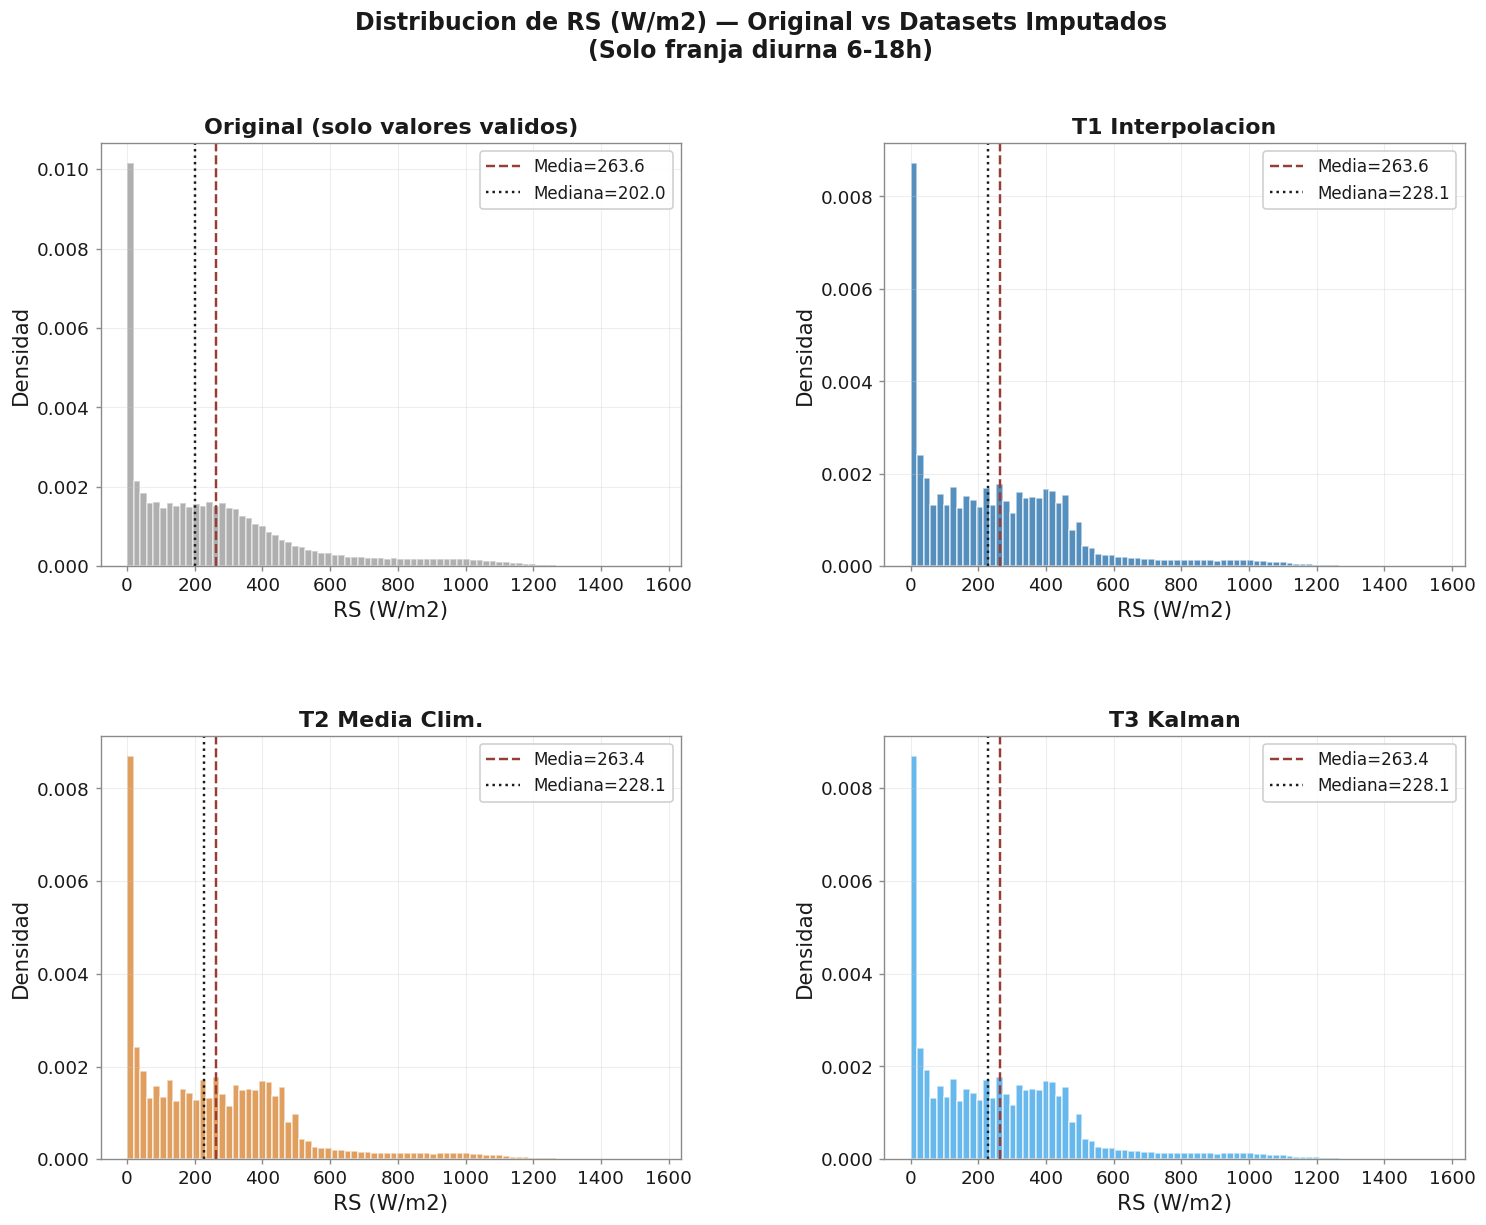

Guardado: fig_03a_distribucion_comparada.svg


In [ ]:
# 4. Distribucion de RS: original vs tres datasets
# Solo horas diurnas para comparacion justa (el original no tiene nocturnos imputados)

mask_diurno = (df_t1.index.hour >= 6) & (df_t1.index.hour <= 18)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Distribucion de RS (W/m2) — Original vs Datasets Imputados\n(Solo franja diurna 6-18h)',
             fontsize=15.5, fontweight='bold')

# Original
ax0  = fig.add_subplot(gs[0, 0])
rs_o = df_orig.loc[df_orig.index.hour.isin(range(6, 19)), 'RS'].dropna()
ax0.hist(rs_o, bins=80, color=C_GRIS, alpha=0.55, density=True, edgecolor='white')
ax0.axvline(rs_o.mean(),   color=C_TEJA,  lw=1.6, ls='--', label=f'Media={rs_o.mean():.1f}')
ax0.axvline(rs_o.median(), color=C_TEXTO, lw=1.6, ls=':',  label=f'Mediana={rs_o.median():.1f}')
ax0.set_title('Original (solo valores validos)')
ax0.set_xlabel('RS (W/m2)')
ax0.set_ylabel('Densidad')
ax0.legend(fontsize=11)
ax0.grid(True, alpha=0.3)

# Los tres datasets
posiciones = [(0,1), (1,0), (1,1)]
for (fi, ci), (key, df) in zip(posiciones, DATASETS.items()):
    ax  = fig.add_subplot(gs[fi, ci])
    rs  = df.loc[mask_diurno, 'RS']
    ax.hist(rs, bins=80, color=COLORES[key], alpha=0.7, density=True, edgecolor='white')
    ax.axvline(rs.mean(),   color=C_TEJA,  lw=1.6, ls='--', label=f'Media={rs.mean():.1f}')
    ax.axvline(rs.median(), color=C_TEXTO, lw=1.6, ls=':',  label=f'Mediana={rs.median():.1f}')
    ax.set_title(ETIQUETAS[key])
    ax.set_xlabel('RS (W/m2)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

guardar_figura(plt.gcf(), 'fig_03a_distribucion_comparada')
plt.show()
print('Guardado: fig_03a_distribucion_comparada.svg')

  Figura guardada: fig_03b_qqplot_comparado.png, .svg y .pdf


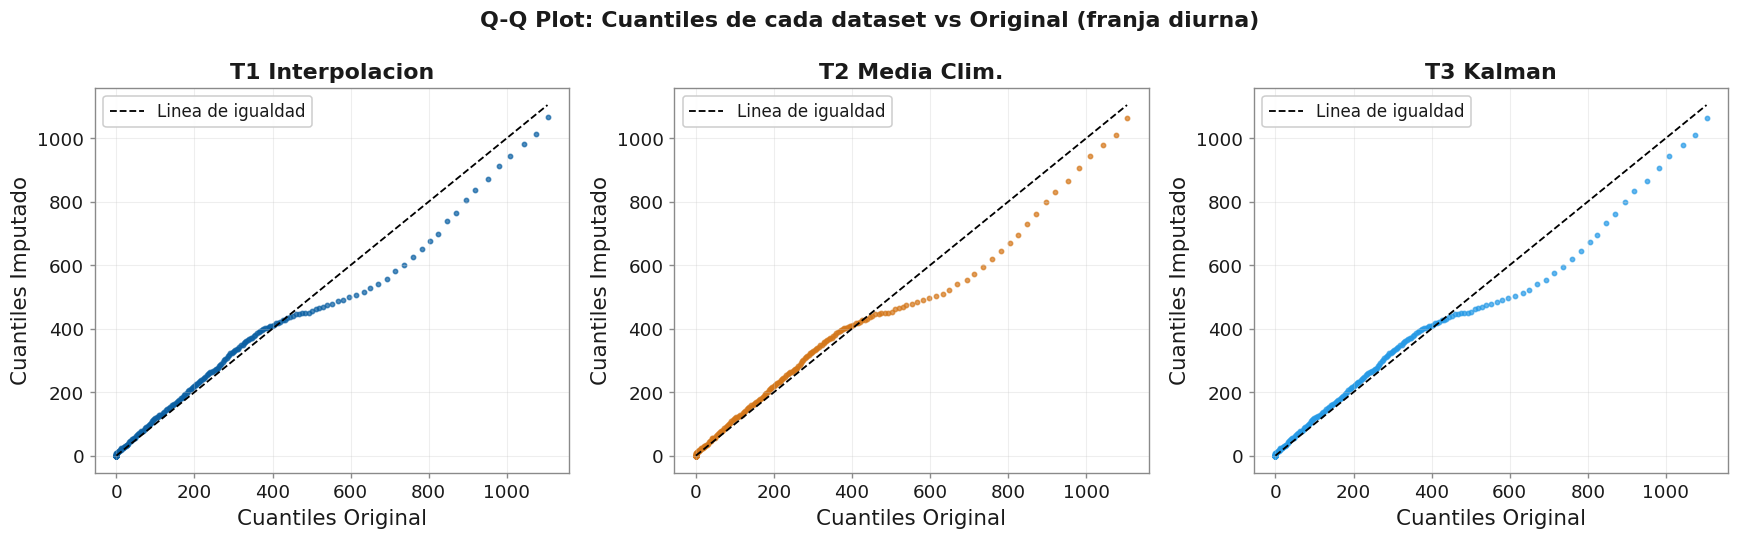

Guardado: fig_03b_qqplot_comparado.svg


In [ ]:
# Q-Q plot: comparacion de cuantiles de cada dataset vs el original
# Un Q-Q plot lineal indica que las distribuciones tienen la misma forma.
# Desviaciones en los extremos revelan diferencias en las colas.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q-Q Plot: Cuantiles de cada dataset vs Original (franja diurna)',
             fontsize=14.5, fontweight='bold')

n_muestra = min(10000, len(rs_o))
q_orig    = np.quantile(rs_o.sample(n_muestra, random_state=SEED), np.linspace(0.01, 0.99, 200))

for ax, (key, df) in zip(axes, DATASETS.items()):
    rs_imp  = df.loc[mask_diurno, 'RS']
    q_imp   = np.quantile(rs_imp.sample(n_muestra, random_state=SEED), np.linspace(0.01, 0.99, 200))
    ax.scatter(q_orig, q_imp, s=8, color=COLORES[key], alpha=0.7)
    lim = max(q_orig.max(), q_imp.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Linea de igualdad')
    ax.set_title(ETIQUETAS[key])
    ax.set_xlabel('Cuantiles Original')
    ax.set_ylabel('Cuantiles Imputado')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_03b_qqplot_comparado')
plt.show()
print('Guardado: fig_03b_qqplot_comparado.svg')

PERFIL MENSUAL EN LA FRANJA DIURNA
  Cobertura observada: 52 % (min) a 89 % (max), media 69 %
  Diferencia media |T1 - original| sobre la franja diurna: 0.27 W/m2
  Figura guardada: fig_03c_patrones_temporales_comparados.png, .svg y .pdf


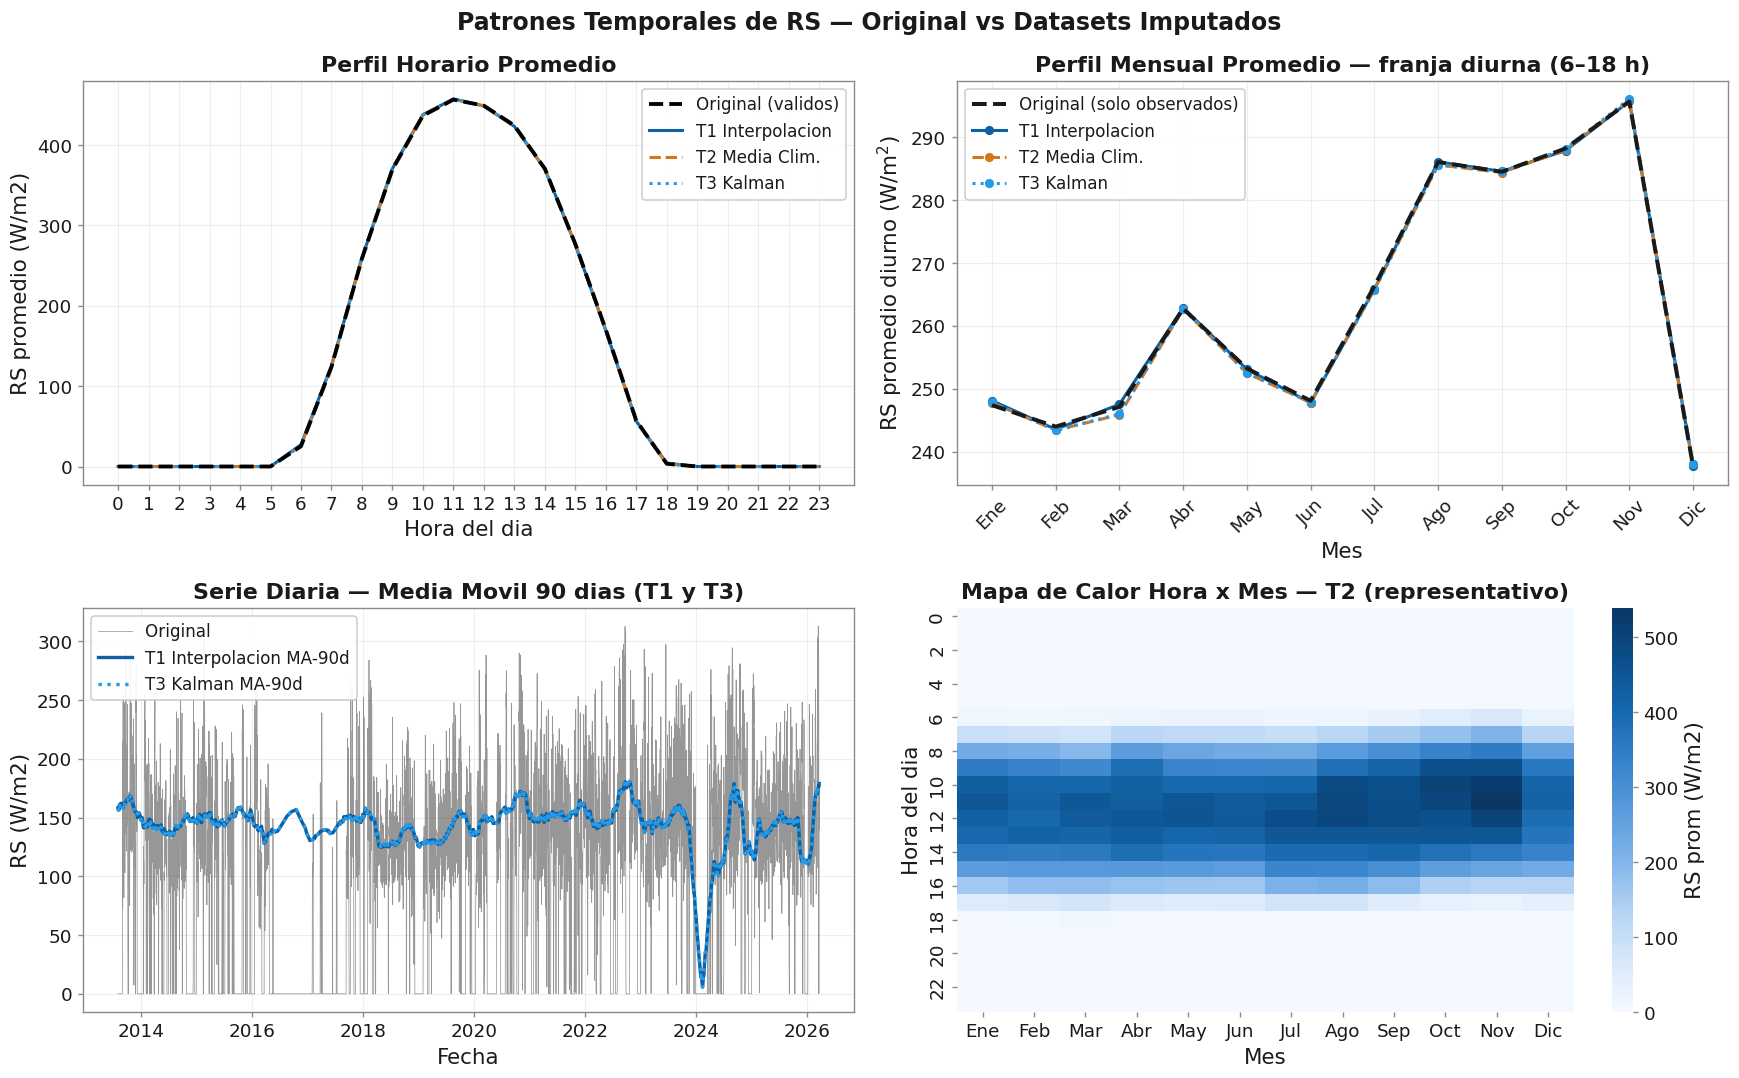

Guardado: fig_03c_patrones_temporales_comparados.svg


In [ ]:
# 5. Patrones temporales comparados
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Patrones Temporales de RS — Original vs Datasets Imputados',
             fontsize=15.5, fontweight='bold')

# Perfil horario
ax = axes[0, 0]
ph_orig = df_orig['RS'].groupby(df_orig.index.hour).mean()
ax.plot(ph_orig.index, ph_orig.values, 'k--', lw=2.5,
        label='Original (validos)', zorder=5)
for key, df in DATASETS.items():
    ph = df['RS'].groupby(df.index.hour).mean()
    ax.plot(ph.index, ph.values, color=COLORES[key], lw=2.0,
            ls=TRAZO[key], label=ETIQUETAS[key])
ax.set_title('Perfil Horario Promedio')
ax.set_xlabel('Hora del dia')
ax.set_ylabel('RS promedio (W/m2)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Perfil mensual — SOBRE LA FRANJA DIURNA
#
# PARCHE DE LA REVISION. Antes este panel promediaba el dia completo. Como al
# original le falta cerca de un tercio de los puntos DIURNOS, en su media los
# ceros de la noche pesaban proporcionalmente mas y su curva caia 20-40 W/m2 por
# debajo de las imputadas. No era que la imputacion perdiera la tendencia: era
# que las dos medias no se tomaban sobre el mismo conjunto de instantes. En la
# franja diurna no hay ceros de noche que diluyan, y las curvas se comparan.
ax = axes[0, 1]
_md = np.asarray((df_orig.index.hour >= 6) & (df_orig.index.hour <= 18))
_mes = df_orig.index.month

def _media_mes(serie, mask):
    v = np.asarray(serie, dtype=float)
    m = np.asarray(mask) & ~np.isnan(v)
    return pd.Series(v[m], index=np.asarray(_mes)[m]).groupby(level=0).mean()

pm_orig = _media_mes(df_orig['RS'], _md)
ax.plot(pm_orig.index, pm_orig.values, color=C_TEXTO, ls='--', lw=2.6,
        label='Original (solo observados)', zorder=5)
for key, df in DATASETS.items():
    pm = _media_mes(df['RS'], _md)
    ax.plot(pm.index, pm.values, color=COLORES[key], lw=2.0, ls=TRAZO[key],
            marker='o', ms=5, label=ETIQUETAS[key])
ax.set_title('Perfil Mensual Promedio — franja diurna (6–18 h)')
ax.set_xlabel('Mes')
ax.set_ylabel('RS promedio diurno (W/m$^2$)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MES_ETIQ, rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

_cob = pd.Series(np.asarray(df_orig['RS'], dtype=float)[_md],
                 index=_mes[_md]).groupby(level=0).apply(lambda s: s.notna().mean()*100)
_dif = float(np.mean(np.abs(_media_mes(DATASETS['T1']['RS'], _md) - pm_orig)))
print('PERFIL MENSUAL EN LA FRANJA DIURNA')
print(f'  Cobertura observada: {_cob.min():.0f} % (min) a {_cob.max():.0f} % (max), '
      f'media {_cob.mean():.0f} %')
print(f'  Diferencia media |T1 - original| sobre la franja diurna: {_dif:.2f} W/m2')

# Serie anual (promedio diario) — solo T1 y T2 para claridad
ax = axes[1, 0]
rs_d_orig = df_orig['RS'].resample('D').mean()
ax.plot(rs_d_orig.index, rs_d_orig.values,
        color=C_TEXTO, lw=0.5, alpha=0.45, label='Original')
for key in ['T1', 'T3']:
    rs_d = DATASETS[key]['RS'].resample('D').mean()
    rs_ma = rs_d.rolling(90, center=True, min_periods=30).mean()
    ax.plot(rs_ma.index, rs_ma.values, color=COLORES[key], lw=2.2,
            ls=TRAZO[key], label=f'{ETIQUETAS[key]} MA-90d')
ax.set_title('Serie Diaria — Media Movil 90 dias (T1 y T3)')
ax.set_ylabel('RS (W/m2)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
eje_fechas(ax)

# Mapa de calor hora x mes — T2 (representativo, igual para T1 y T3)
ax = axes[1, 1]
df_hm = pd.DataFrame({
    'h'  : df_t2.index.hour,
    'm'  : df_t2.index.month,
    'RS' : df_t2['RS'].values
})
pivot = df_hm.groupby(['h', 'm'])['RS'].mean().unstack()
sns.heatmap(pivot, ax=ax, cmap='tg_azul',
            xticklabels=MES_ETIQ,
            cbar_kws={'label': 'RS prom (W/m2)'})
ax.set_title('Mapa de Calor Hora x Mes — T2 (representativo)')
ax.set_xlabel('Mes')
ax.set_ylabel('Hora del dia')

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_03c_patrones_temporales_comparados')
plt.show()
print('Guardado: fig_03c_patrones_temporales_comparados.svg')

  Figura guardada: fig_03d_boxplot_hora_comparado.png, .svg y .pdf


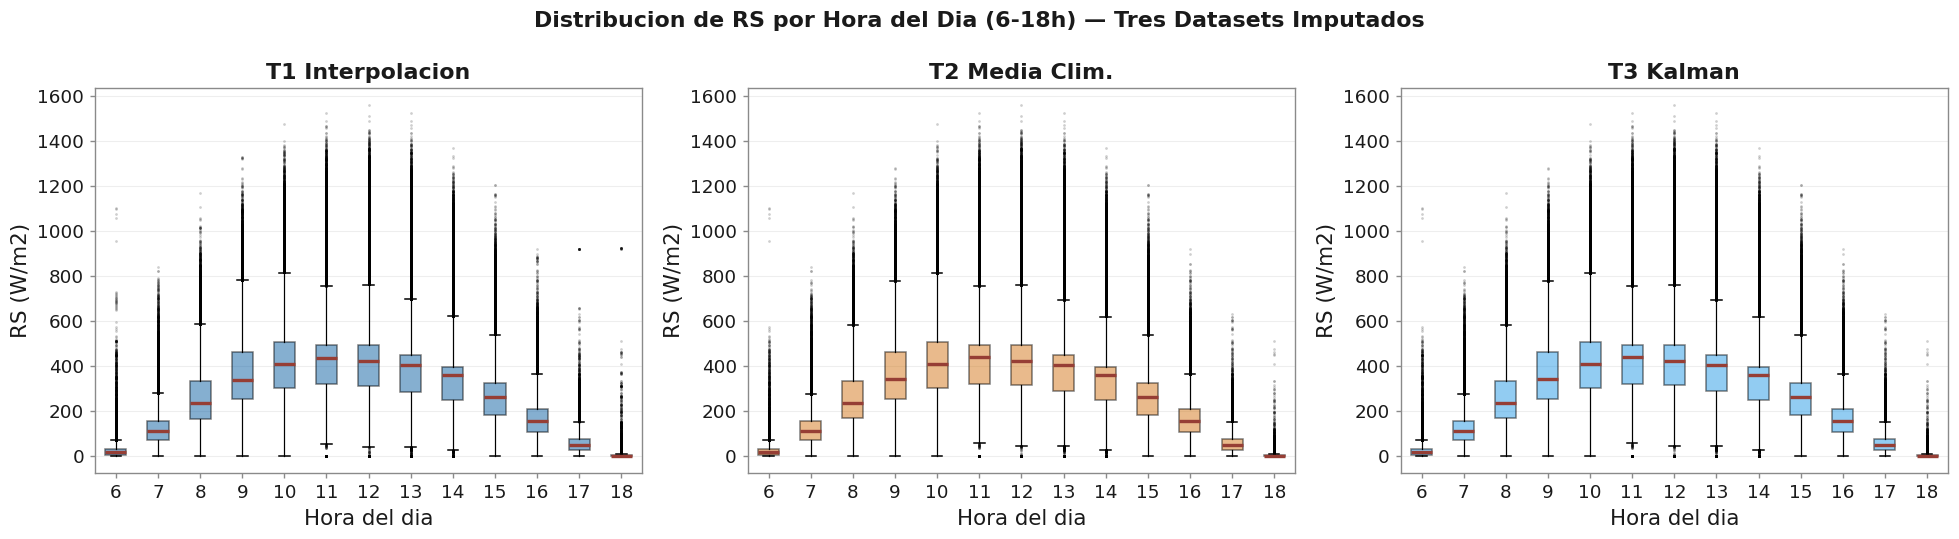

Guardado: fig_03d_boxplot_hora_comparado.svg


In [ ]:
# Boxplot de RS por hora del dia — comparacion entre datasets (franja diurna)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribucion de RS por Hora del Dia (6-18h) — Tres Datasets Imputados',
             fontsize=14.5, fontweight='bold')

for ax, (key, df) in zip(axes, DATASETS.items()):
    df_box   = pd.DataFrame({'h': df.index.hour, 'RS': df['RS'].values})
    df_box   = df_box[(df_box['h'] >= 6) & (df_box['h'] <= 18)]
    datos_bp = [df_box[df_box['h'] == h]['RS'].values for h in range(6, 19)]
    ax.boxplot(
        datos_bp, labels=range(6, 19),
        patch_artist=True,
        boxprops=dict(facecolor=COLORES[key], alpha=0.5),
        medianprops=dict(color=C_TEJA, lw=2.2),
        flierprops=dict(marker='.', ms=1.5, alpha=0.2),
        whiskerprops=dict(lw=0.8)
    )
    ax.set_title(ETIQUETAS[key])
    ax.set_xlabel('Hora del dia')
    ax.set_ylabel('RS (W/m2)')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_03d_boxplot_hora_comparado')
plt.show()
print('Guardado: fig_03d_boxplot_hora_comparado.svg')

ANALISIS DEL INDICE DE CLARIDAD KT
  Max diferencia KT T1-T2: 0.000000  (debe ser ~0)
  Max diferencia KT T1-T3: 0.000000  (debe ser ~0)

  Estadisticas KT (franja diurna):
    Media   : 0.5772
    Mediana : 0.5737
    Std     : 0.1327
    Min     : 0.0551
    Max     : 0.9988

  Clasificacion del cielo (franja diurna):
    Cubierto   (KT < 0.3) :  13,296  (1.84%)
    Parcial    (0.3-0.6)  : 405,623  (56.28%)
    Despejado  (KT > 0.6) : 301,801  (41.87%)
  Figura guardada: fig_03e_kt_analisis.png, .svg y .pdf


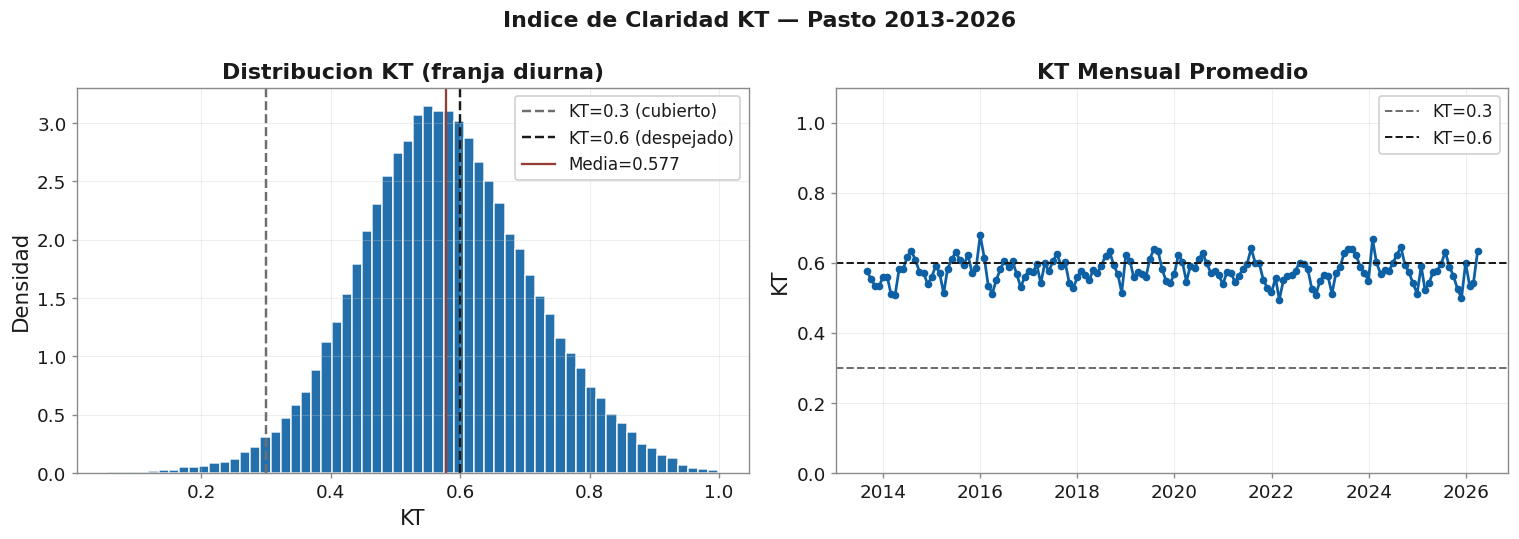

Guardado: fig_03e_kt_analisis.svg


In [ ]:
# 6. Analisis del indice de claridad KT
# KT = ALLSKY_SFC_SW_DWN / CLRSKY_SFC_SW_DWN
# KT ~ 1.0 = cielo despejado | KT ~ 0 = cielo completamente nublado
# Los tres datasets comparten las mismas variables NASA POWER, por lo que
# el KT deberia ser identico entre ellos. Lo verificamos y analizamos.

if 'KT' in df_t1.columns:
    print('ANALISIS DEL INDICE DE CLARIDAD KT')
    print('=' * 50)

    # Verificar que KT es identico en los tres datasets
    diff_kt_12 = (df_t1['KT'] - df_t2['KT']).abs().max()
    diff_kt_13 = (df_t1['KT'] - df_t3['KT']).abs().max()
    print(f'  Max diferencia KT T1-T2: {diff_kt_12:.6f}  (debe ser ~0)')
    print(f'  Max diferencia KT T1-T3: {diff_kt_13:.6f}  (debe ser ~0)')

    kt = df_t1['KT']  # identico en los tres
    kt_diurno = kt[(df_t1.index.hour >= 6) & (df_t1.index.hour <= 18)]

    print(f'\n  Estadisticas KT (franja diurna):')
    print(f'    Media   : {kt_diurno.mean():.4f}')
    print(f'    Mediana : {kt_diurno.median():.4f}')
    print(f'    Std     : {kt_diurno.std():.4f}')
    print(f'    Min     : {kt_diurno.min():.4f}')
    print(f'    Max     : {kt_diurno.max():.4f}')

    # Clasificacion del cielo segun KT
    # KT < 0.3  = cielo cubierto
    # 0.3-0.6   = parcialmente nublado
    # KT > 0.6  = cielo despejado
    n_cubierto   = (kt_diurno < 0.3).sum()
    n_parcial    = ((kt_diurno >= 0.3) & (kt_diurno < 0.6)).sum()
    n_despejado  = (kt_diurno >= 0.6).sum()
    n_tot        = len(kt_diurno)

    print(f'\n  Clasificacion del cielo (franja diurna):')
    print(f'    Cubierto   (KT < 0.3) : {n_cubierto:>7,}  ({n_cubierto/n_tot*100:.2f}%)')
    print(f'    Parcial    (0.3-0.6)  : {n_parcial:>7,}  ({n_parcial/n_tot*100:.2f}%)')
    print(f'    Despejado  (KT > 0.6) : {n_despejado:>7,}  ({n_despejado/n_tot*100:.2f}%)')

    # Visualizacion KT
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Indice de Claridad KT — Pasto 2013-2026', fontsize=14.5, fontweight='bold')

    # Distribucion
    axes[0].hist(kt_diurno, bins=60, color=C_AZUL, alpha=0.9, edgecolor='white', density=True)
    axes[0].axvline(0.3, color=C_GRIS,  lw=1.6, ls='--', label='KT=0.3 (cubierto)')
    axes[0].axvline(0.6, color=C_TEXTO, lw=1.6, ls='--', label='KT=0.6 (despejado)')
    axes[0].axvline(kt_diurno.mean(), color=C_TEJA, lw=1.5, ls='-',
                     label=f'Media={kt_diurno.mean():.3f}')
    axes[0].set_title('Distribucion KT (franja diurna)')
    axes[0].set_xlabel('KT')
    axes[0].set_ylabel('Densidad')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # KT mensual promedio
    kt_mes = kt_diurno.resample('ME').mean()
    axes[1].plot(kt_mes.index, kt_mes.values, color=C_AZUL, lw=1.8, marker='o', ms=4)
    axes[1].axhline(0.3, color=C_GRIS,  lw=1.3, ls='--', label='KT=0.3')
    axes[1].axhline(0.6, color=C_TEXTO, lw=1.3, ls='--', label='KT=0.6')
    axes[1].set_title('KT Mensual Promedio')
    axes[1].set_ylabel('KT')
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    eje_fechas(axes[1])

    plt.tight_layout()
    guardar_figura(plt.gcf(), 'fig_03e_kt_analisis')
    plt.show()
    print('Guardado: fig_03e_kt_analisis.svg')
else:
    print('KT no disponible (NASA POWER no integrado)')

In [ ]:
# 7. Analisis descriptivo de variables NASA POWER
VARS_NASA = ['ALLSKY_SFC_SW_DWN','CLRSKY_SFC_SW_DWN','T2M','RH2M',
             'PRECTOTCORR','WS10M','WD10M','PS','SZA','KT']
VARS_NASA = [v for v in VARS_NASA if v in df_t1.columns]

print('ESTADISTICAS DESCRIPTIVAS — VARIABLES NASA POWER')
print('(Identicas en los tres datasets — se muestra una sola vez)')
print('=' * 60)

desc_nasa = df_t1[VARS_NASA].describe().T
desc_nasa['cv_%'] = (desc_nasa['std'] / desc_nasa['mean'].abs() * 100).round(2)
print(desc_nasa.round(3).to_string())
desc_nasa.to_csv(os.path.join(RUTA_DATOS, 'tabla_03_descriptivas_nasa_power.csv'))
print('\nGuardado: tabla_03_descriptivas_nasa_power.csv')

ESTADISTICAS DESCRIPTIVAS — VARIABLES NASA POWER
(Identicas en los tres datasets — se muestra una sola vez)
                       count     mean      std     min      25%      50%      75%       max    cv_%
ALLSKY_SFC_SW_DWN  1330560.0  170.371  223.883   0.000    0.000   15.850  347.915  1024.570  131.41
CLRSKY_SFC_SW_DWN  1330560.0  290.074  366.050   0.000    0.000   26.667  633.901  1090.300  126.19
T2M                1330560.0   13.282    3.000   4.780   10.928   12.700   15.793    22.590   22.58
RH2M               1330560.0   85.360   13.749  29.050   73.349   92.000   96.827   100.000   16.11
PRECTOTCORR        1330560.0    3.254    6.257   0.000    0.142    1.013    3.525   141.060  192.30
WS10M              1330560.0    2.752    1.853   0.010    1.361    2.283    3.735    12.870   67.33
WD10M              1330560.0  141.450   70.395   0.000  111.100  126.983  140.017   359.800   49.77
PS                 1330560.0   75.224    0.122  74.770   75.140   75.227   75.311    75.630 

  Figura guardada: fig_03f_perfiles_nasa_power.png, .svg y .pdf


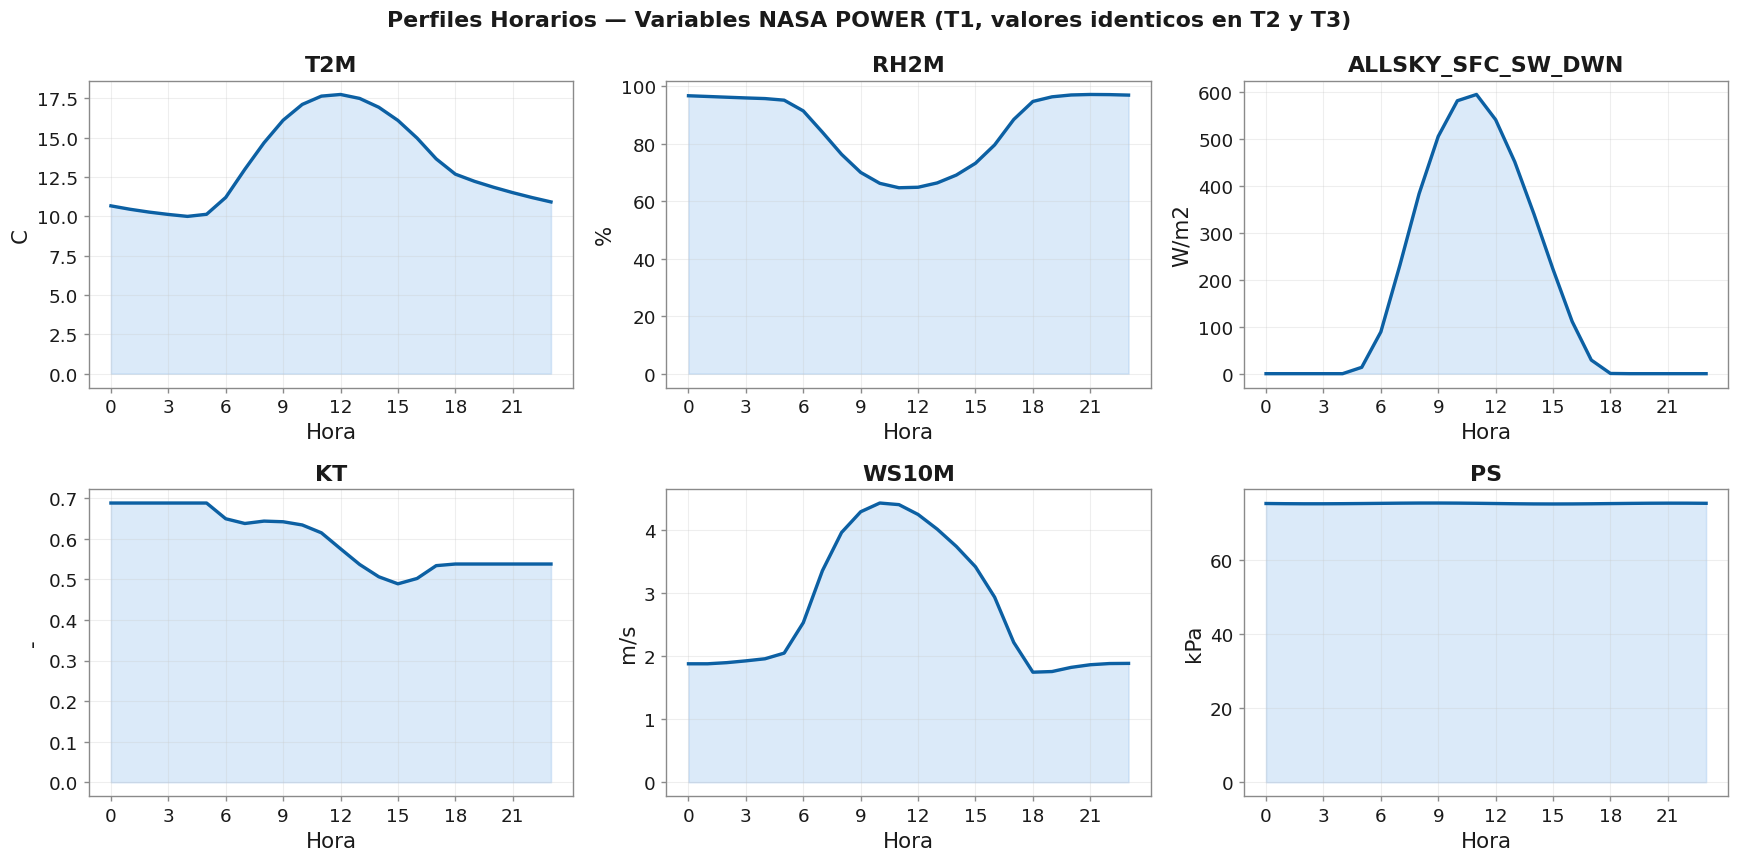

Guardado: fig_03f_perfiles_nasa_power.svg


In [ ]:
# Perfiles horarios de variables NASA POWER
VARS_PERFIL = [v for v in ['T2M','RH2M','ALLSKY_SFC_SW_DWN','KT','WS10M','PS']
               if v in df_t1.columns]

nc = 3
nr = (len(VARS_PERFIL) + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(16, 4 * nr))
axes = axes.flatten()
fig.suptitle('Perfiles Horarios — Variables NASA POWER (T1, valores identicos en T2 y T3)',
             fontsize=14.5, fontweight='bold')

UNIDADES = {
    'T2M': 'C', 'RH2M': '%', 'ALLSKY_SFC_SW_DWN': 'W/m2',
    'KT': '-', 'WS10M': 'm/s', 'PS': 'kPa',
    'PRECTOTCORR': 'mm/h', 'WD10M': 'grados', 'SZA': 'grados',
    'CLRSKY_SFC_SW_DWN': 'W/m2'
}

for i, var in enumerate(VARS_PERFIL):
    ph = df_t1[var].groupby(df_t1.index.hour).mean()
    axes[i].plot(ph.index, ph.values, color=C_AZUL, lw=2.2)
    axes[i].fill_between(ph.index, ph.values, alpha=0.28, color=C_AZUL_CLARO)
    axes[i].set_title(var)
    axes[i].set_xlabel('Hora')
    axes[i].set_ylabel(UNIDADES.get(var, ''))
    axes[i].set_xticks(range(0, 24, 3))
    axes[i].grid(True, alpha=0.3)

for j in range(len(VARS_PERFIL), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_03f_perfiles_nasa_power')
plt.show()
print('Guardado: fig_03f_perfiles_nasa_power.svg')

In [ ]:
# 8. Correlaciones con RS en cada dataset — franja diurna
#
# PARCHE DE LA REVISION: se anade Spearman junto a Pearson.
#
# Que mide realmente esta tabla. Sobre los niveles, la correlacion entre la
# irradiancia y casi cualquier variable con ciclo diurno resulta alta porque
# las dos suben por la manana y bajan por la tarde. Eso no dice que una
# prediga a la otra: dice que las dos siguen al Sol. Ademas, dos variables
# deterministas del calendario, como el angulo cenital o la irradiancia de
# cielo despejado, no son variables aleatorias, y una correlacion entre una
# serie observada y una funcion del reloj no se interpreta como asociacion
# estadistica.
#
# La version que va al documento esta en el cuaderno 10: correlacion sobre
# anomalias respecto de la climatologia, con Spearman en paralelo y con el
# tamano de muestra corregido por autocorrelacion. Esta tabla se conserva como
# descripcion, no como evidencia de asociacion.

print('CORRELACION CON RS — FRANJA DIURNA (6-18 h)')
print('=' * 78)
print('Advertencia: calculada sobre niveles. Sobrestima la asociacion por el')
print('ciclo diurno comun. La version corregida esta en el cuaderno 10.')
print()

VARS_CORR = [v for v in df_t1.columns
             if v not in ['RS', 'hora', 'minuto', 'dia_semana', 'anio', 'es_diurno']]

tabla_corr = {}
for key, df in DATASETS.items():
    df_d = df.loc[mask_diurno]
    tabla_corr[f'{ETIQUETAS[key]} (Pearson)'] = df_d[VARS_CORR + ['RS']].corr(
        method='pearson')['RS'].drop('RS')

df_d1 = DATASETS['T1'].loc[mask_diurno]
tabla_corr['T1 (Spearman)'] = df_d1[VARS_CORR + ['RS']].corr(
    method='spearman')['RS'].drop('RS')

df_corr = pd.DataFrame(tabla_corr)
df_corr = df_corr.sort_values(f'{ETIQUETAS["T1"]} (Pearson)', key=abs, ascending=False)
print(df_corr.round(4).to_string())

DETERMINISTAS = ['SZA', 'CLRSKY_SFC_SW_DWN', 'sin_hora', 'cos_hora',
                 'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes', 'dia_anio', 'mes']
det = [v for v in df_corr.index if v in DETERMINISTAS]
if det:
    print()
    print('Variables deterministas del calendario presentes en la tabla:')
    print('  ' + ', '.join(det))
    print('  Para estas, el coeficiente describe la forma del ciclo diurno, no una')
    print('  asociacion entre dos variables aleatorias. El cuaderno 10 lo desarrolla.')

df_corr.to_csv(os.path.join(RUTA_DATOS, 'tabla_03_correlaciones_rs.csv'))
print()
print('Guardado: tabla_03_correlaciones_rs.csv')

CORRELACION CON RS — FRANJA DIURNA (6-18 h)
Advertencia: calculada sobre niveles. Sobrestima la asociacion por el
ciclo diurno comun. La version corregida esta en el cuaderno 10.

                   T1 Interpolacion (Pearson)  T2 Media Clim. (Pearson)  T3 Kalman (Pearson)  T1 (Spearman)
cos_hora                              -0.6675                   -0.6712              -0.6708        -0.7431
CLRSKY_SFC_SW_DWN                      0.6656                    0.6693               0.6689         0.7348
ALLSKY_SFC_SW_DWN                      0.6625                    0.6654               0.6652         0.7312
SZA                                   -0.6600                   -0.6635              -0.6632        -0.7360
RH2M                                  -0.6017                   -0.6047              -0.6044        -0.6792
T2M                                    0.5788                    0.5817               0.5813         0.6434
WS10M                                  0.2380                   

  Figura guardada: fig_03g_heatmap_correlaciones.png, .svg y .pdf


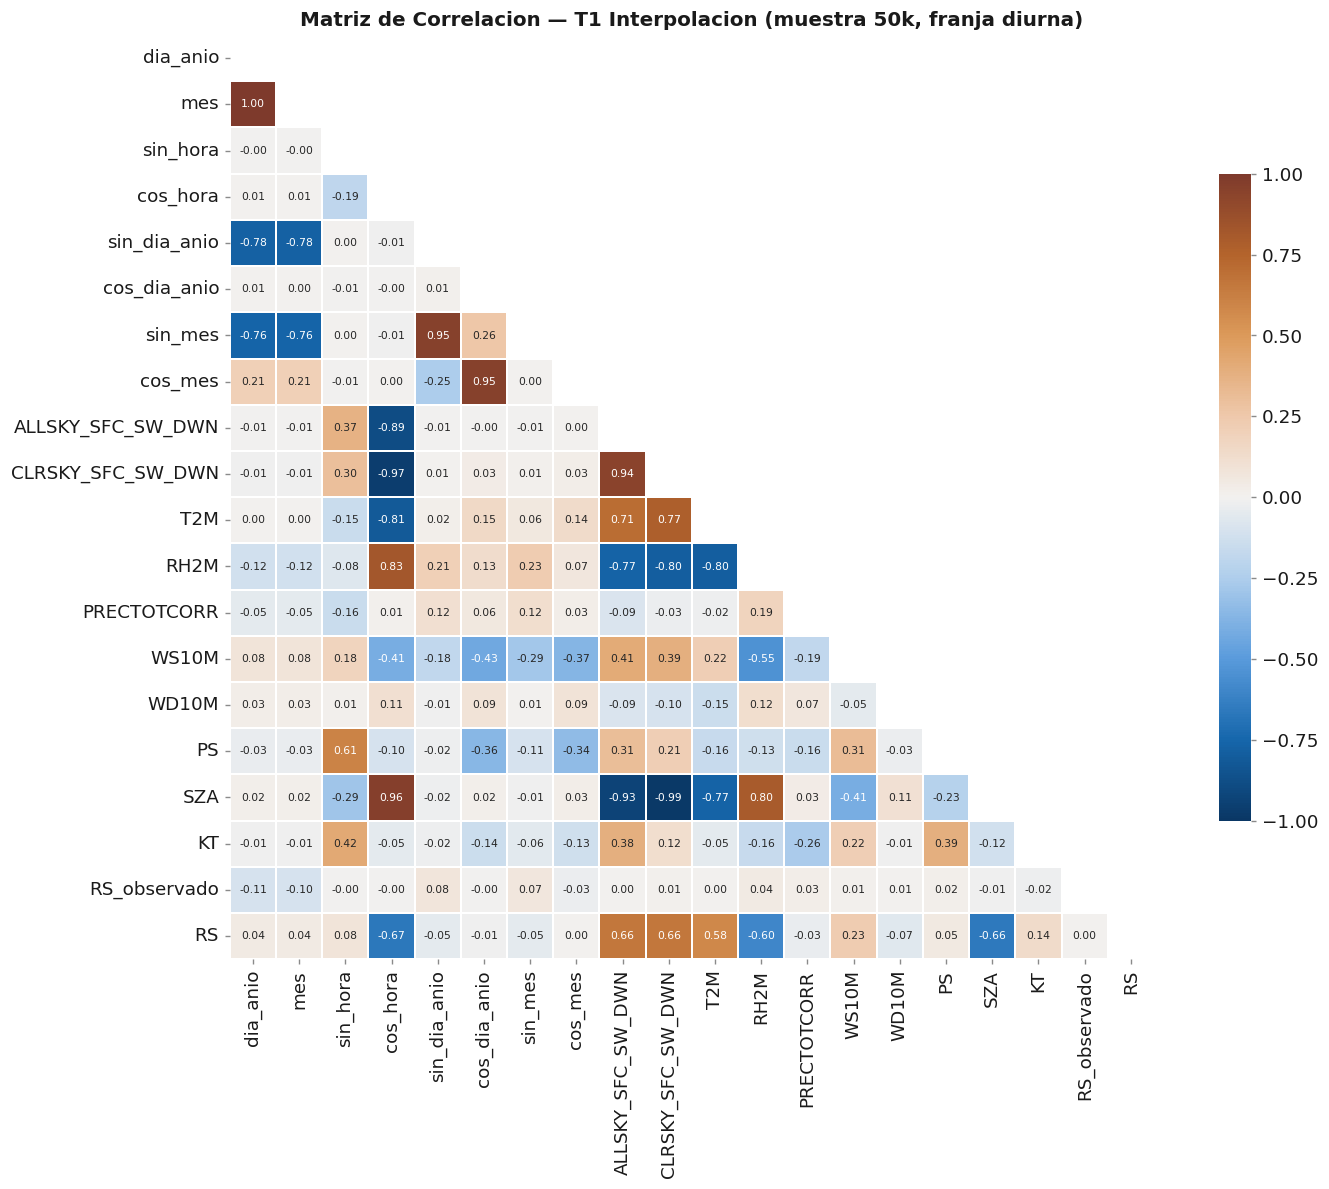

Guardado: fig_03g_heatmap_correlaciones.svg


In [ ]:
# Heatmap de correlaciones — T1 como representativo
n_mu   = min(50000, mask_diurno.sum())
df_mu  = df_t1.loc[mask_diurno, VARS_CORR + ['RS']].sample(n=n_mu, random_state=SEED)
mat    = df_mu.corr()
mask   = np.triu(np.ones_like(mat, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    mat, ax=ax, mask=mask, cmap='tg_div',
    center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Matriz de Correlacion — T1 Interpolacion (muestra 50k, franja diurna)',
             fontsize=13)
plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_03g_heatmap_correlaciones')
plt.show()
print('Guardado: fig_03g_heatmap_correlaciones.svg')

In [ ]:
# 9. Comparacion distribucional de las tres tecnicas
#
# PARCHE DE LA REVISION: este bloque ya no elige la tecnica.
#
# Los criterios de aqui abajo comprueban que una tecnica no deforma el
# conjunto. Es una condicion necesaria: una imputacion que corriera la media o
# aplastara las colas seria inaceptable. Pero no es suficiente, porque no dice
# cual acierta. Quien lo dice es el experimento de ocultamiento del cuaderno 09.

print('COMPARACION DISTRIBUCIONAL DE LAS TRES TECNICAS')
print('=' * 70)
print('Condicion necesaria: ninguna tecnica debe deformar el conjunto.')
print()

media_orig = df_orig['RS'].mean()
print('1. Diferencia de medias respecto al original:')
for key, df in DATASETS.items():
    print(f'   {ETIQUETAS[key]}: {abs(df["RS"].mean() - media_orig)/media_orig*100:.4f} %')

std_orig = df_orig['RS'].std()
print()
print('2. Diferencia de desviacion estandar respecto al original:')
for key, df in DATASETS.items():
    print(f'   {ETIQUETAS[key]}: {abs(df["RS"].std() - std_orig)/std_orig*100:.4f} %')

print()
print('3. Diferencia absoluta media entre tecnicas:')
print(f'   |T1-T2|: {(df_t1["RS"] - df_t2["RS"]).abs().mean():.4f} W/m2')
print(f'   |T1-T3|: {(df_t1["RS"] - df_t3["RS"]).abs().mean():.4f} W/m2')
print(f'   |T2-T3|: {(df_t2["RS"] - df_t3["RS"]).abs().mean():.4f} W/m2')

print()
print('4. Prueba de Kolmogorov-Smirnov frente al original (franja diurna, n=5000):')
n_ks = 5000
orig_d = rs_o.sample(n_ks, random_state=SEED)
for key, df in DATASETS.items():
    ks_st, ks_p = scipy_stats.ks_2samp(orig_d, df.loc[mask_diurno, 'RS'].sample(
        n_ks, random_state=SEED))
    print(f'   {ETIQUETAS[key]}: estadistico={ks_st:.4f}, p={ks_p:.4f}')

# --- Criterio de exactitud: viene del cuaderno 09 --------------------------
print()
print('=' * 70)
print('CRITERIO DE EXACTITUD — validacion por ocultamiento (cuaderno 09)')
print('=' * 70)

ruta_val = os.path.join(RUTA_DATOS, 'tabla_09_validacion_imputacion.csv')
TECNICA_ELEGIDA = None
if os.path.exists(ruta_val):
    val = pd.read_csv(ruta_val)
    glob_ = val[val['clase'] == 'Todas'].sort_values('RMSE')
    print(glob_.round(3).to_string(index=False))
    TECNICA_ELEGIDA = glob_.iloc[0]['tecnica']
    print()
    print(f'  Menor error frente a la verdad oculta: {TECNICA_ELEGIDA}')
    print('  Esta es la tecnica que alimenta el modelado, y la razon es que')
    print('  acierta mas, no que deforme menos.')
    largas = val[val['clase'] == 'Racha > 2h']
    if len(largas):
        print()
        print('  En rachas largas (> 2 h):')
        print('  ' + largas.sort_values('RMSE').round(3).to_string(index=False
              ).replace('\n', '\n  '))
else:
    print('  AVISO: no se encontro tabla_09_validacion_imputacion.csv.')
    print('  Ejecuta el cuaderno 09 antes que este; sin ese resultado, la')
    print('  eleccion de tecnica se quedaria sin justificacion de exactitud.')

COMPARACION DISTRIBUCIONAL DE LAS TRES TECNICAS
Condicion necesaria: ninguna tecnica debe deformar el conjunto.

1. Diferencia de medias respecto al original:
   T1 Interpolacion: 20.4795 %
   T2 Media Clim.: 20.3596 %
   T3 Kalman: 20.3865 %

2. Diferencia de desviacion estandar respecto al original:
   T1 Interpolacion: 0.5174 %
   T2 Media Clim.: 0.7891 %
   T3 Kalman: 0.7718 %

3. Diferencia absoluta media entre tecnicas:
   |T1-T2|: 0.8941 W/m2
   |T1-T3|: 0.8056 W/m2
   |T2-T3|: 0.0898 W/m2

4. Prueba de Kolmogorov-Smirnov frente al original (franja diurna, n=5000):
   T1 Interpolacion: estadistico=0.0450, p=0.0001
   T2 Media Clim.: estadistico=0.0456, p=0.0001
   T3 Kalman: estadistico=0.0456, p=0.0001

CRITERIO DE EXACTITUD — validacion por ocultamiento (cuaderno 09)
                tecnica clase     n     MAE    RMSE   sesgo  corr
    T3 filtro de Kalman Todas 54153 143.737 209.982   3.408 0.609
 T2 media climatologica Todas 54153 143.890 210.105   3.534 0.609
T1 interpolacio

In [ ]:
# 10. Resumen ejecutivo
recomendado = TECNICA_ELEGIDA if TECNICA_ELEGIDA else 'PENDIENTE — ejecutar el cuaderno 09'

print('=' * 72)
print('RESUMEN EJECUTIVO — NOTEBOOK 03, EDA POST-PREPROCESAMIENTO')
print('=' * 72)
print(f'''
CONJUNTO
  Registros  : {len(df_t1):,}  |  Periodo: {df_t1.index.min().date()} a {df_t1.index.max().date()}
  Variables  : {df_t1.shape[1]}  |  Resolucion: 5 minutos
  Fuentes    : estacion CESMAG (RS) + NASA POWER (9 variables meteorologicas)

CALIDAD POST-IMPUTACION
  NaN en RS en los tres conjuntos : 0
  RS negativa                     : 0
  RS mayor que 1600 W/m2          : 0
  RS positiva en horario nocturno : 0

ESTADISTICAS DE RS POST-IMPUTACION
  T1 (interpolacion): media={df_t1["RS"].mean():.2f}  std={df_t1["RS"].std():.2f}
  T2 (media climat.): media={df_t2["RS"].mean():.2f}  std={df_t2["RS"].std():.2f}
  T3 (Kalman)       : media={df_t3["RS"].mean():.2f}  std={df_t3["RS"].std():.2f}
  Original (validos): media={df_orig["RS"].mean():.2f}  std={df_orig["RS"].std():.2f}

VARIABLES DISPONIBLES PARA MODELADO
  Objetivo    : RS (irradiancia solar, W/m2)
  Temporales  : sin/cos de hora, dia del anio y mes; indicador de franja diurna
  Satelitales : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR, WS10M, WD10M, PS, SZA
  Derivada    : indice de claridad (calculado en el cuaderno 02, con umbral
                minimo en el denominador)

CONJUNTO SELECCIONADO PARA MODELADO
  Tecnica : {recomendado}
  Razon   : menor error frente a la verdad oculta en la validacion del
            cuaderno 09. Los criterios distribucionales de este cuaderno
            confirman que ninguna de las tres deforma el conjunto, que es
            una condicion necesaria pero no un criterio de seleccion.
  Las otras dos quedan disponibles para el analisis de sensibilidad.
''')

print('Figuras generadas:')
for f in sorted(x for x in os.listdir(RUTA_FIGS_SVG) if x.startswith('fig_03')):
    tam = os.path.getsize(os.path.join(RUTA_FIGS_SVG, f)) / 1024
    print(f'  {f:<52} ({tam:>7.1f} KB)')

RESUMEN EJECUTIVO — NOTEBOOK 03, EDA POST-PREPROCESAMIENTO

CONJUNTO
  Registros  : 1,330,560  |  Periodo: 2013-08-01 a 2026-03-25
  Variables  : 25  |  Resolucion: 5 minutos
  Fuentes    : estacion CESMAG (RS) + NASA POWER (9 variables meteorologicas)

CALIDAD POST-IMPUTACION
  NaN en RS en los tres conjuntos : 0
  RS negativa                     : 0
  RS mayor que 1600 W/m2          : 0
  RS positiva en horario nocturno : 0

ESTADISTICAS DE RS POST-IMPUTACION
  T1 (interpolacion): media=142.80  std=221.35
  T2 (media climat.): media=142.66  std=220.75
  T3 (Kalman)       : media=142.69  std=220.78
  Original (validos): media=118.53  std=222.50

VARIABLES DISPONIBLES PARA MODELADO
  Objetivo    : RS (irradiancia solar, W/m2)
  Temporales  : sin/cos de hora, dia del anio y mes; indicador de franja diurna
  Satelitales : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR, WS10M, WD10M, PS, SZA
  Derivada    : indice de claridad (calculado en el cuaderno 02, con umbral
                minimo en el d